In [1]:
import sys
from pathlib import Path
import time
import json

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, TensorDataset

def find_project_root(marker="data/imagenet100"):
    current = Path.cwd()
    for parent in [current, *current.parents]:
        if (parent / marker).exists():
            return parent
    raise FileNotFoundError(f"Could not find project root containing {marker}")

PROJECT_ROOT = find_project_root()
EMBEDDINGS_DIR = PROJECT_ROOT / "data" / "embeddings"
CHECKPOINTS_DIR = PROJECT_ROOT / "checkpoints"
RESULTS_DIR = PROJECT_ROOT / "results"
CHECKPOINTS_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Device: {device}")

Device: mps


In [2]:
def load_embeddings(split):
    path = EMBEDDINGS_DIR / f"{split}_embeddings.pt"
    data = torch.load(path, weights_only=True)
    return data["features"], data["labels"]


train_features, train_labels = load_embeddings("train")
val_features, val_labels = load_embeddings("val")
heldout_features, heldout_labels = load_embeddings("heldout")

train_dataset = TensorDataset(train_features, train_labels)
val_dataset = TensorDataset(val_features, val_labels)
heldout_dataset = TensorDataset(heldout_features, heldout_labels)

BATCH_SIZE = 512

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
heldout_loader = DataLoader(heldout_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"Train: {len(train_features):,} samples, {len(train_loader)} batches")
print(f"Val:   {len(val_features):,} samples, {len(val_loader)} batches")
print(f"Heldout: {len(heldout_features):,} samples, {len(heldout_loader)} batches")

Train: 117,000 samples, 229 batches
Val:   13,000 samples, 26 batches
Heldout: 5,000 samples, 10 batches


In [3]:
class CosinePrototypeClassifier(nn.Module):
    """
    Prototype-based classifier with cosine similarity.
    
    Maintains a bank of learnable prototypes Π ∈ R^[n_classes, embed_dim].
    For each input x, computes cosine similarity to each prototype, scaled by
    a learnable temperature τ to produce logits suitable for cross-entropy.
    
    logit_i = τ · cos(x, Π_i) = τ · (x · Π_i) / (||x|| · ||Π_i||)
    
    Args:
        embed_dim: dimensionality of input features (2048)
        n_classes: number of output classes (100)
        init_temperature: initial value for τ (default 10.0)
    """
    def __init__(self, embed_dim=2048, n_classes=100, init_temperature=10.0):
        super().__init__()
        # Prototype bank — randomly initialized
        # Shape [n_classes, embed_dim] mirrors nn.Linear's [out, in] convention
        self.prototypes = nn.Parameter(torch.randn(n_classes, embed_dim))
        
        # Learnable temperature, initialized to init_temperature
        # Stored as a scalar parameter
        self.temperature = nn.Parameter(torch.tensor(float(init_temperature)))
    
    def forward(self, x):
        # x has shape [B, embed_dim]
        # self.prototypes has shape [n_classes, embed_dim]
        
        # Normalize both to unit length along the feature dimension
        x_norm = F.normalize(x, p=2, dim=1)                        # [B, embed_dim]
        proto_norm = F.normalize(self.prototypes, p=2, dim=1)      # [n_classes, embed_dim]
        
        # Cosine similarities via matrix multiplication
        # [B, embed_dim] @ [embed_dim, n_classes] -> [B, n_classes]
        cosine_sim = x_norm @ proto_norm.T
        
        # Scale by temperature to get logits
        logits = self.temperature * cosine_sim
        return logits


# Instantiate and inspect
model = CosinePrototypeClassifier(embed_dim=2048, n_classes=100, init_temperature=10.0).to(device)

n_params = sum(p.numel() for p in model.parameters())
n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model: {model}")
print(f"Total parameters: {n_params:,}")
print(f"Trainable parameters: {n_trainable:,}")
print(f"\nPrototype bank shape: {model.prototypes.shape}")
print(f"Initial temperature: {model.temperature.item():.4f}")

Model: CosinePrototypeClassifier()
Total parameters: 204,801
Trainable parameters: 204,801

Prototype bank shape: torch.Size([100, 2048])
Initial temperature: 10.0000


In [4]:
features, labels = next(iter(train_loader))
features = features.to(device)
labels = labels.to(device)

logits = model(features)

print(f"Input shape:  {features.shape}")
print(f"Output shape: {logits.shape}")
print(f"Output dtype: {logits.dtype}")
print(f"Output stats: mean={logits.mean():.4f}, std={logits.std():.4f}")
print(f"Output range: [{logits.min():.4f}, {logits.max():.4f}]")
print(f"Random prediction accuracy: {(logits.argmax(dim=1) == labels).float().mean():.4f}")

Input shape:  torch.Size([512, 2048])
Output shape: torch.Size([512, 100])
Output dtype: torch.float32
Output stats: mean=0.0021, std=0.2247
Output range: [-0.8324, 0.9322]
Random prediction accuracy: 0.0059


In [5]:
# Diagnose the cosine similarity distribution
with torch.no_grad():
    features, labels = next(iter(train_loader))
    features = features.to(device)
    
    x_norm = F.normalize(features, p=2, dim=1)
    proto_norm = F.normalize(model.prototypes, p=2, dim=1)
    cosine_sim = x_norm @ proto_norm.T  # raw cosine, no temperature
    
    print(f"Raw cosine similarity stats (no temperature):")
    print(f"  Shape: {cosine_sim.shape}")
    print(f"  Mean:  {cosine_sim.mean():.4f}")
    print(f"  Std:   {cosine_sim.std():.4f}")
    print(f"  Min:   {cosine_sim.min():.4f}")
    print(f"  Max:   {cosine_sim.max():.4f}")
    
    # Check the input embeddings — are they actually unit-norm-friendly?
    norms = features.norm(dim=1)
    print(f"\nInput feature norms:")
    print(f"  Mean:  {norms.mean():.4f}")
    print(f"  Std:   {norms.std():.4f}")
    print(f"  Range: [{norms.min():.4f}, {norms.max():.4f}]")
    
    # And the prototype norms
    proto_norms = model.prototypes.norm(dim=1)
    print(f"\nPrototype norms:")
    print(f"  Mean:  {proto_norms.mean():.4f}")
    print(f"  Range: [{proto_norms.min():.4f}, {proto_norms.max():.4f}]")

Raw cosine similarity stats (no temperature):
  Shape: torch.Size([512, 100])
  Mean:  0.0002
  Std:   0.0224
  Min:   -0.0911
  Max:   0.0891

Input feature norms:
  Mean:  5.4623
  Std:   0.5609
  Range: [3.3254, 8.4130]

Prototype norms:
  Mean:  45.3485
  Range: [43.7500, 47.5739]


In [6]:
# Same training loop as Step 8 — define here for notebook self-containedness

def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    total_correct = 0
    total_samples = 0
    
    for features, labels in loader:
        features = features.to(device)
        labels = labels.to(device)
        
        logits = model(features)
        loss = criterion(logits, labels)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item() * features.size(0)
        total_correct += (logits.argmax(dim=1) == labels).sum().item()
        total_samples += features.size(0)
    
    return total_loss / total_samples, total_correct / total_samples


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_samples = 0
    
    for features, labels in loader:
        features = features.to(device)
        labels = labels.to(device)
        
        logits = model(features)
        loss = criterion(logits, labels)
        
        total_loss += loss.item() * features.size(0)
        total_correct += (logits.argmax(dim=1) == labels).sum().item()
        total_samples += features.size(0)
    
    return total_loss / total_samples, total_correct / total_samples


def fit(model, train_loader, val_loader, optimizer, criterion, device, n_epochs):
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": [], "temperature": []}
    
    print(f"{'Epoch':>5} | {'Train Loss':>10} | {'Train Acc':>9} | "
          f"{'Val Loss':>9} | {'Val Acc':>8} | {'τ':>6} | {'Time':>6}")
    print("-" * 80)
    
    for epoch in range(1, n_epochs + 1):
        start = time.time()
        train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
        val_loss, val_acc = evaluate(model, val_loader, criterion, device)
        tau = model.temperature.item()
        elapsed = time.time() - start
        
        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        history["temperature"].append(tau)
        
        print(f"{epoch:>5} | {train_loss:>10.4f} | {train_acc:>8.2%} | "
              f"{val_loss:>9.4f} | {val_acc:>7.2%} | {tau:>6.2f} | {elapsed:>5.1f}s")
    
    return history


# Hyperparameters (identical to Step 8 for fair comparison)
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
N_EPOCHS = 30

# Fresh model
model = CosinePrototypeClassifier(embed_dim=2048, n_classes=100, init_temperature=10.0).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

print(f"Training cosine prototype classifier for {N_EPOCHS} epochs")
print(f"Initial temperature: {model.temperature.item():.4f}\n")

history = fit(model, train_loader, val_loader, optimizer, criterion, device, n_epochs=N_EPOCHS)

print(f"\nFinal temperature: {model.temperature.item():.4f}")
print(f"Best validation accuracy: {max(history['val_acc']):.4f} (epoch {history['val_acc'].index(max(history['val_acc'])) + 1})")

Training cosine prototype classifier for 30 epochs
Initial temperature: 10.0000

Epoch | Train Loss | Train Acc |  Val Loss |  Val Acc |      τ |   Time
--------------------------------------------------------------------------------
    1 |     4.5422 |    3.06% |    4.4511 |   7.35% |  10.15 |   2.9s
    2 |     4.3293 |   18.00% |    4.1869 |  32.15% |  10.57 |   1.7s
    3 |     4.0076 |   46.06% |    3.8088 |  57.72% |  10.99 |   1.8s
    4 |     3.5733 |   64.49% |    3.3265 |  68.97% |  11.39 |   1.7s
    5 |     3.0551 |   72.29% |    2.7890 |  74.25% |  11.78 |   1.9s
    6 |     2.5193 |   75.88% |    2.2743 |  76.64% |  12.13 |   1.7s
    7 |     2.0434 |   77.87% |    1.8515 |  78.15% |  12.45 |   1.7s
    8 |     1.6744 |   79.16% |    1.5406 |  79.18% |  12.72 |   1.8s
    9 |     1.4107 |   80.12% |    1.3237 |  80.26% |  12.95 |   1.8s
   10 |     1.2276 |   80.99% |    1.1732 |  80.90% |  13.16 |   1.6s
   11 |     1.1002 |   81.71% |    1.0691 |  81.55% |  13.35 |   1

In [7]:
checkpoint_path = CHECKPOINTS_DIR / "cosine_prototype_classifier.pt"
torch.save({
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    "history": history,
    "hyperparameters": {
        "embed_dim": 2048,
        "n_classes": 100,
        "learning_rate": LEARNING_RATE,
        "weight_decay": WEIGHT_DECAY,
        "n_epochs": N_EPOCHS,
        "batch_size": BATCH_SIZE,
        "optimizer": "Adam",
        "init_temperature": 10.0,
    },
    "final_metrics": {
        "train_loss": history["train_loss"][-1],
        "train_acc": history["train_acc"][-1],
        "val_loss": history["val_loss"][-1],
        "val_acc": history["val_acc"][-1],
        "best_val_acc": max(history["val_acc"]),
        "best_val_epoch": history["val_acc"].index(max(history["val_acc"])) + 1,
        "final_temperature": model.temperature.item(),
    },
}, checkpoint_path)

print(f"Saved checkpoint to {checkpoint_path}")

Saved checkpoint to /Users/ayushkumarsingh/ABNS-Project/tversky-asymmetric/checkpoints/cosine_prototype_classifier.pt


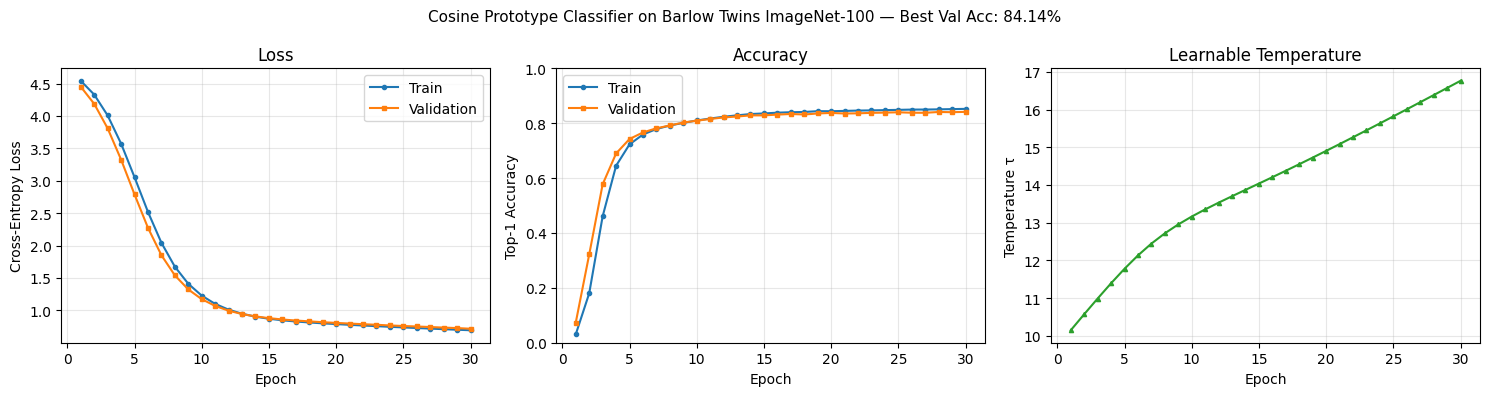

Saved plot to /Users/ayushkumarsingh/ABNS-Project/tversky-asymmetric/results/cosine_prototype_curves.png


In [8]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

epochs = range(1, len(history["train_loss"]) + 1)

axes[0].plot(epochs, history["train_loss"], label="Train", marker="o", markersize=3)
axes[0].plot(epochs, history["val_loss"], label="Validation", marker="s", markersize=3)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Cross-Entropy Loss")
axes[0].set_title("Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs, history["train_acc"], label="Train", marker="o", markersize=3)
axes[1].plot(epochs, history["val_acc"], label="Validation", marker="s", markersize=3)
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Top-1 Accuracy")
axes[1].set_title("Accuracy")
axes[1].set_ylim(0.0, 1.0)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].plot(epochs, history["temperature"], marker="^", markersize=3, color="C2")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("Temperature τ")
axes[2].set_title("Learnable Temperature")
axes[2].grid(True, alpha=0.3)

plt.suptitle(f"Cosine Prototype Classifier on Barlow Twins ImageNet-100 — "
             f"Best Val Acc: {max(history['val_acc']):.2%}", fontsize=11)
plt.tight_layout()

plot_path = RESULTS_DIR / "cosine_prototype_curves.png"
plt.savefig(plot_path, dpi=120, bbox_inches="tight")
plt.show()

print(f"Saved plot to {plot_path}")